# Free energy of phase field sinteting model

This free energy function includes 2 sets of order parameters (field variables): 1) for solid versus vapor phases, and 2) for grains with the solid. 


The total free energy of the system will be the integration of the bulk free energy and the interfacial energies over the domain:

$$\mathcal{F} = \int f(\rho, \eta_i) + \frac{1}{2}\varepsilon_\rho \big| \nabla \rho \big|^2 + \sum_i \frac{1}{2} \varepsilon_\eta \big| \nabla \eta_i \big|^2 d\Omega.$$

The bulk free energy functional is given as

$$f(\rho,\eta_i) = \alpha \rho^2 (1-\rho)^2 + \beta \bigg[ \rho^2 + 6\big(1-\rho\big) \sum_i \eta_i^2 -4 \big(2-\rho) \sum_i \eta_i^3 + 3 \bigg( \sum_i \eta^2 \bigg)^2 \bigg].$$

Since it's very difficult to visualize a function over 3 dimensions, let's us a free energy function of 3 grains to understand this bulk free energy functional.

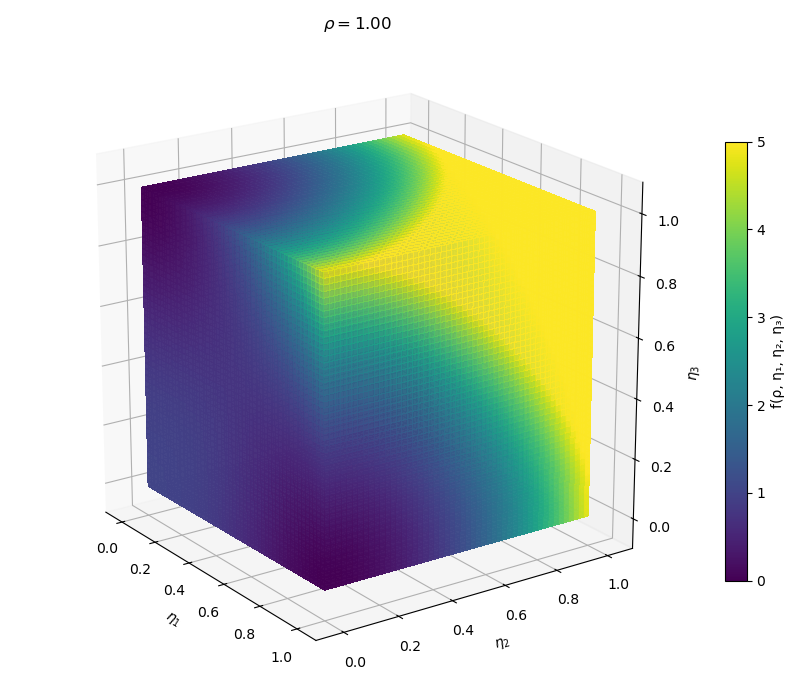

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for 3D)
%matplotlib ipympl

# --- parameters ---
alpha = 16.0
beta = 1.0

# grids (51 points from 0 to 1)
rho = np.linspace(0.0, 1.0, 51)
eta = np.linspace(0.0, 1.0, 51)

# Choose which rho-slice to visualize:
#   idx=0  -> rho=0.0
#   idx=50 -> rho=1.0 (matches the MATLAB title '\rho = 1')
rho_idx = 50  # change to 0 if you want rho=0
rho_val = rho[rho_idx]

# 3D grids for eta1, eta2, eta3
E1, E2, E3 = np.meshgrid(eta, eta, eta, indexing='ij')

# --- compute f at the chosen rho (vectorized, no 4D array needed) ---
Esqr_sum = E1**2 + E2**2 + E3**2
Ecub_sum = E1**3 + E2**3 + E3**3

f_rho = (alpha* rho_val**2 * (1.0 - rho_val)**2
    + beta * (rho_val**2 + 6.0 * (1.0 - rho_val) * Esqr_sum
    - 4.0 * (2.0 - rho_val) * Ecub_sum + 3.0 * (Esqr_sum**2)))


# --- coordinates for plotting (same 0:0.02:1 grid) ---
X, Y, Z = np.meshgrid(eta, eta, eta, indexing='ij')

# colored by f_rho on those faces.
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# normalize colors like caxis([0,5])
vmin, vmax = 0.0, 5.0
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

alpha = 0.85

# x=0 face (i=0)
ax.plot_surface(
    X[0, :, :], Y[0, :, :], Z[0, :, :],
    facecolors=cmap(norm(f_rho[0, :, :])), rstride=1, cstride=1,
    linewidth=0, antialiased=False, shade=False, alpha=alpha
)

# x=1 face (i=-1)
ax.plot_surface(
    X[-1, :, :], Y[-1, :, :], Z[-1, :, :],
    facecolors=cmap(norm(f_rho[-1, :, :])), rstride=1, cstride=1,
    linewidth=0, antialiased=False, shade=False, alpha=alpha
)

# y=0 face (j=0)
ax.plot_surface(
    X[:, 0, :], Y[:, 0, :], Z[:, 0, :],
    facecolors=cmap(norm(f_rho[:, 0, :])), rstride=1, cstride=1,
    linewidth=0, antialiased=False, shade=False, alpha=alpha
)

# y=1 face (j=-1)
ax.plot_surface(
    X[:, -1, :], Y[:, -1, :], Z[:, -1, :],
    facecolors=cmap(norm(f_rho[:, -1, :])), rstride=1, cstride=1,
    linewidth=0, antialiased=False, shade=False, alpha=alpha
)

# z=0 face (k=0)
ax.plot_surface(
    X[:, :, 0], Y[:, :, 0], Z[:, :, 0],
    facecolors=cmap(norm(f_rho[:, :, 0])), rstride=1, cstride=1,
    linewidth=0, antialiased=False, shade=False, alpha=alpha
)

# z=1 face (k=-1)
ax.plot_surface(
    X[:, :, -1], Y[:, :, -1], Z[:, :, -1],
    facecolors=cmap(norm(f_rho[:, :, -1])), rstride=1, cstride=1,
    linewidth=0, antialiased=False, shade=False, alpha=alpha
)

# cosmetics (labels, limits, colorbar)
mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, fraction=0.03, pad=0.06)
cbar.set_label('f(ρ, η₁, η₂, η₃)')

ax.set_xlabel(r'$\eta_{1}$')
ax.set_ylabel(r'$\eta_{2}$')
ax.set_zlabel(r'$\eta_{3}$')
ax.set_title(rf'$\rho = {rho_val:.2f}$')

ax.set_box_aspect([1, 1, 1])
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_zlim(-0.1, 1.1)
ax.view_init(elev=20, azim=-35)  # similar to view(3)
plt.tight_layout()
plt.show()
